<a href="https://colab.research.google.com/github/priyansh-commits/Deep_Learning/blob/main/rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

model = Sequential([
    layers.Input(shape=(5,)),       # 5 tokens per sentence
    layers.Embedding(
        input_dim=1000,             # vocabulary size
        output_dim=16                # vector size per token
    ),
    layers.SimpleRNN(32),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 16)          │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,601 (68.75 KB)

 Trainable params: 17,601 (68.75 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
import tensorflow as tf
from tensorflow.keras import *
from tensorflow.keras.preprocessing.text import *
from tensorflow.keras.layers import *

In [5]:
import numpy as np

docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [10]:

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding

# Our text dataset
texts = [
    "I love machine learning",
    "I love deep learning",
    "I hate machine learning"
]

# STEP 1: TOKENIZATION + VECTORIZATION
vectorizer = TextVectorization(
    max_tokens=100,
    output_mode="int",
    output_sequence_length=4
)

# Learn the vocabulary from our text
vectorizer.adapt(texts)

# Convert sentences into token IDs
token_ids = vectorizer(tf.constant(texts))

print("Vocabulary:", vectorizer.get_vocabulary())
print("\nToken IDs:\n", token_ids.numpy())

# STEP 2: EMBEDDING
embedding_layer = Embedding(
    input_dim=100,
    output_dim=4
)

# Convert each token ID into a 4-dimensional vector
embedded_text = embedding_layer(token_ids)

print("\nEmbedding shape:", embedded_text.shape)
print("\nEmbedded vectors:\n", embedded_text.numpy())

Vocabulary: ['', '[UNK]', np.str_('learning'), np.str_('i'), np.str_('machine'), np.str_('love'), np.str_('hate'), np.str_('deep')]

Token IDs:
 [[3 5 4 2]
 [3 5 7 2]
 [3 6 4 2]]

Embedding shape: (3, 4, 4)

Embedded vectors:
 [[[-0.00594668  0.00603019 -0.01207923 -0.00255639]
  [-0.00977319  0.02881533 -0.04602239  0.00136914]
  [-0.04759085  0.01620977 -0.00818454 -0.02922137]
  [-0.01161152  0.0383851   0.00024278 -0.04918003]]

 [[-0.00594668  0.00603019 -0.01207923 -0.00255639]
  [-0.00977319  0.02881533 -0.04602239  0.00136914]
  [-0.0068687  -0.03706717  0.00424253 -0.00800224]
  [-0.01161152  0.0383851   0.00024278 -0.04918003]]

 [[-0.00594668  0.00603019 -0.01207923 -0.00255639]
  [-0.01736218 -0.02625158 -0.03560636 -0.03580169]
  [-0.04759085  0.01620977 -0.00818454 -0.02922137]
  [-0.01161152  0.0383851   0.00024278 -0.04918003]]]


In [9]:

from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "I love machine learning",
    "I love deep learning",
    "I hate machine learning"
]

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(texts)

print("Features:", tfidf.get_feature_names_out())
print("TF-IDF matrix:\n", X.toarray())
print("Shape:", X.shape)

Features: ['deep' 'hate' 'learning' 'love' 'machine']
TF-IDF matrix:
 [[0.         0.         0.48133417 0.61980538 0.61980538]
 [0.72033345 0.         0.42544054 0.54783215 0.        ]
 [0.         0.72033345 0.42544054 0.         0.54783215]]
Shape: (3, 5)


SMALL WORKING ON IMDB DATASET

In [11]:

from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "I love machine learning",
    "I love deep learning",
    "I hate machine learning"
]

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(texts)

print("Features:", tfidf.get_feature_names_out())
print("TF-IDF matrix:\n", X.toarray())
print("Shape:", X.shape)

Features: ['deep' 'hate' 'learning' 'love' 'machine']
TF-IDF matrix:
 [[0.         0.         0.48133417 0.61980538 0.61980538]
 [0.72033345 0.         0.42544054 0.54783215 0.        ]
 [0.         0.72033345 0.42544054 0.         0.54783215]]
Shape: (3, 5)


In [12]:

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    TextVectorization, Embedding,
    SimpleRNN, Dense
)

# 1. Data
texts = [
    "i love this movie",
    "this movie is amazing",
    "i really like it",
    "this is wonderful",
    "i hate this movie",
    "this movie is terrible",
    "i really dislike it",
    "this is awful"
]

# 1 = positive, 0 = negative
labels = [1, 1, 1, 1, 0, 0, 0, 0]

# 2. Tokenization + vectorization
vectorizer = TextVectorization(
    max_tokens=1000,
    output_sequence_length=6
)
vectorizer.adapt(texts)

X = vectorizer(tf.constant(texts))
y = tf.constant(labels)

print("Token IDs:\n", X.numpy())

# 3. RNN model with embedding
model = Sequential([
    tf.keras.Input(shape=(6,)),
    Embedding(
        input_dim=len(vectorizer.get_vocabulary()),
        output_dim=16,
        mask_zero=True
    ),
    SimpleRNN(16),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 4. Train
model.fit(X, y, epochs=30, verbose=1)

# 5. Predict on new text
test_text = ["i love this movie"]
test_ids = vectorizer(tf.constant(test_text))

probability = model.predict(test_ids, verbose=0)[0][0]

print("Positive probability:", probability)
print("Prediction:", "Positive" if probability >= 0.5 else "Negative")

Token IDs:
 [[ 5 10  2  3  0  0]
 [ 2  3  4 15  0  0]
 [ 5  6 11  7  0  0]
 [ 2  4  8  0  0  0]
 [ 5 12  2  3  0  0]
 [ 2  3  4  9  0  0]
 [ 5  6 13  7  0  0]
 [ 2  4 14  0  0  0]]
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5000 - loss: 0.6855
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5000 - loss: 0.6830
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.5000 - loss: 0.6805
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5000 - loss: 0.6780
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.7500 - loss: 0.6754
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7500 - loss: 0.6728
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7500 - loss: 0.6701
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7500 - loss: 0.6673
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7500 - loss: 0.6645
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.75

In [55]:
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=25000)


In [56]:
print("Number of reviews:", len(X_train))
print("First review length:", len(X_train[0]))
print("Second review length:", len(X_train[1]))

Number of reviews: 25000
First review length: 218
Second review length: 189


In [57]:
X_train = pad_sequences(X_train,padding='post',maxlen=150)
X_test = pad_sequences(X_test,padding='post',maxlen=150)


In [58]:
model=Sequential()
model.add(Embedding(25000,16,input_length=150))
model.add(SimpleRNN(32))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [60]:
callbacks = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[callbacks]
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.5785 - loss: 0.6667 - val_accuracy: 0.6539 - val_loss: 0.6380
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.7103 - loss: 0.5738 - val_accuracy: 0.7922 - val_loss: 0.4805
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7726 - loss: 0.4781 - val_accuracy: 0.8162 - val_loss: 0.4688
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.8442 - loss: 0.3593 - val_accuracy: 0.5905 - val_loss: 0.7152
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8992 - loss: 0.2554 - val_accuracy: 0.8151 - val_loss: 0.4998
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9038 - loss: 0.2352 - val_accuracy: 0.5996 - val_loss: 0.8883


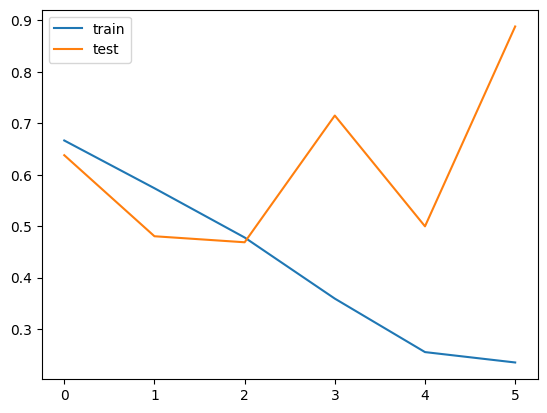

In [61]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','test'])
plt.show()

In [62]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8162 - loss: 0.4688
Test accuracy: 0.8162400126457214
